# Análise Exploratória dos Dados

Nessa etapa, iremos explorar os nossos dados, analisando estatísticas, correlações, valores faltantes e outliers.

## Importando as Bibliotecas

Vamos carregar nossas bibliotecas.

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

## Carregando o Dataset

Agora vamos carregar o nosso dataset.

In [40]:
df = pd.read_parquet("../data/processed/02_enriched.parquet")

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tipo_imovel             7919 non-null   object 
 1   preco                   7919 non-null   Int64  
 2   condominio              4602 non-null   Int64  
 3   area_m2                 7919 non-null   Int64  
 4   quartos                 7918 non-null   Int64  
 5   banheiros               7918 non-null   Int64  
 6   vagas                   7286 non-null   Int64  
 7   piscina                 7919 non-null   boolean
 8   espaco_gourmet          7919 non-null   boolean
 9   academia                7919 non-null   boolean
 10  spa_massagem            7919 non-null   boolean
 11  espaco_lazer            7919 non-null   boolean
 12  area_trabalho           7919 non-null   boolean
 13  espaco_infantil         7919 non-null   boolean
 14  area_esportiva          7919 non-null   boolean
 15

## Análise de Correlação

Vamos inicialmente fazer uma análise de correlação entre algumas variáveis. Para isso, vamos remover a feature `tipo_imovel` e vamos converter todas as features para o tipo `float`.

In [42]:
df = df.drop("tipo_imovel", axis="columns").astype("float64")

In [43]:
corr = df.corr(method="spearman")

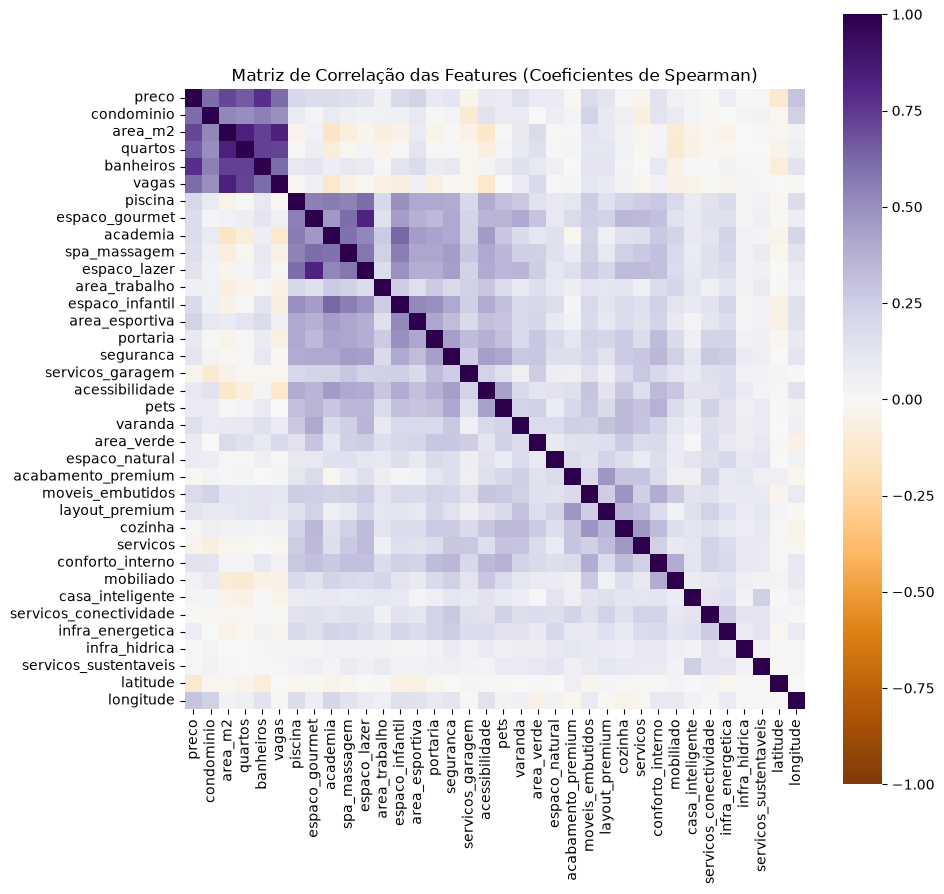

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sns.heatmap(
    data=corr,
    annot=False,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Coeficientes de Spearman)")

plt.show()

Como podemos ver, as features `area_m2`, `banheiros` e `quartos` possuem uma correlação positiva alta com a variável alvo `preço`. Podemos esperar que essas features tenham um bom poder preditivo quando treinarmos nossos modelos, então não seria surpresa se durante a etapa de modelagem nos depararmos com um valor alto de importância para essas features.

Agora, vamos analisar os valores de correlação das primeiras 6 features.

In [45]:
corr_6 = df[df.columns[:6]].corr(method="spearman")

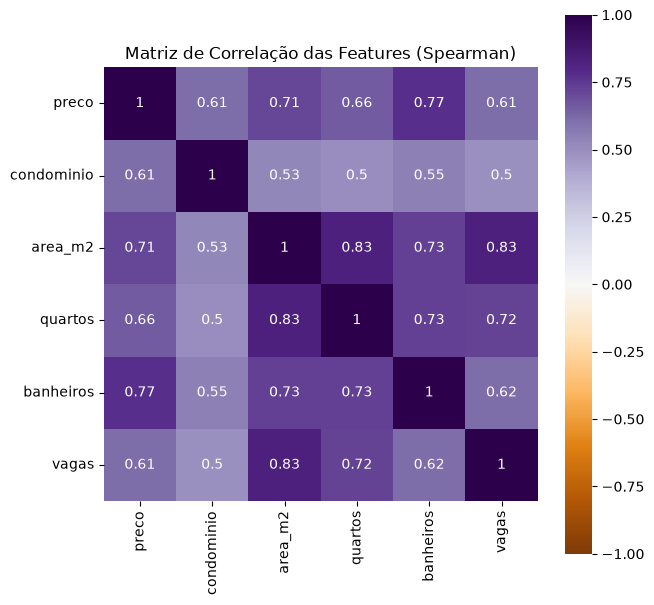

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sns.heatmap(
    data=corr_6,
    annot=True,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Spearman)")

plt.show()

Esses valores podem nos dar uma noção de como nossos modelos vão se comportar na etapa de modelagem.

## Análise de Dados Faltantes

Agora vamos olhar para os dados faltantes do nosso dataset. Primeiro, vamos olhar as porcentagens de dados faltantes nas features do nosso dataset.

In [47]:
df_na_count = df.isna().sum()
total = df.shape[0]

df_missing = pd.DataFrame({
    "Contagem de NA": df_na_count,
    "Porcentagem": (100*df_na_count / total).round(2),
})

df_missing = df_missing.sort_values(
    by="Contagem de NA",
    ascending=False
)

print(df_missing.to_string())

                        Contagem de NA  Porcentagem
condominio                        3317        41.89
vagas                              633         7.99
banheiros                            1         0.01
quartos                              1         0.01
area_m2                              0         0.00
preco                                0         0.00
piscina                              0         0.00
espaco_gourmet                       0         0.00
academia                             0         0.00
spa_massagem                         0         0.00
espaco_lazer                         0         0.00
area_trabalho                        0         0.00
espaco_infantil                      0         0.00
area_esportiva                       0         0.00
portaria                             0         0.00
seguranca                            0         0.00
servicos_garagem                     0         0.00
acessibilidade                       0         0.00
pets        

Como podemos ver, apenas as features `condominio`, `vagas`, `banheiros` e `quartos` possuem valores faltantes, sendo os $2$ últimos de baixíssima frequência. Como as duas últimas possuem uma quantidade muito baixa de valores faltantes, então vamos prosseguir a análise apenas com as $2$ primeiras features.

In [48]:
df_miss = df[["condominio", "vagas"]]

<Axes: >

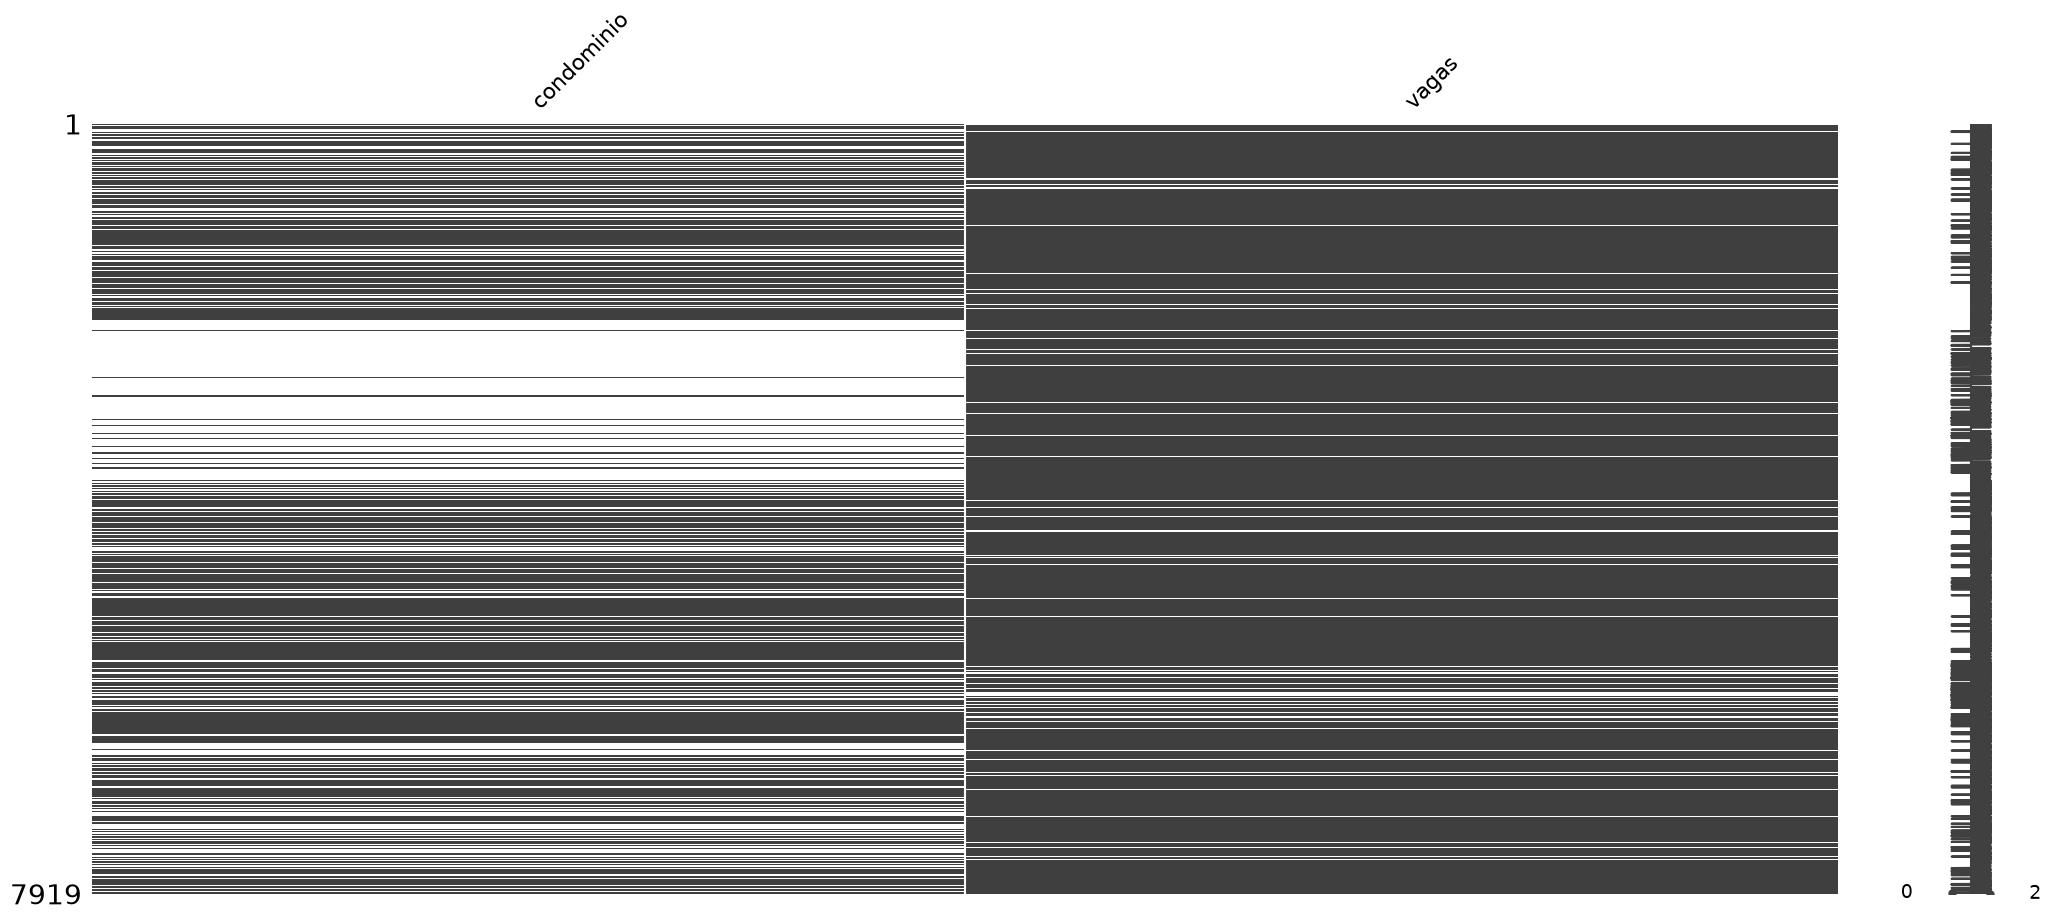

In [49]:
msno.matrix(df_miss)

Bom, a princípio não parece ter nenhum padrão nos valores faltantes. Vamos então olhar para as correlações dos valores faltantes dessas features.

<Axes: >

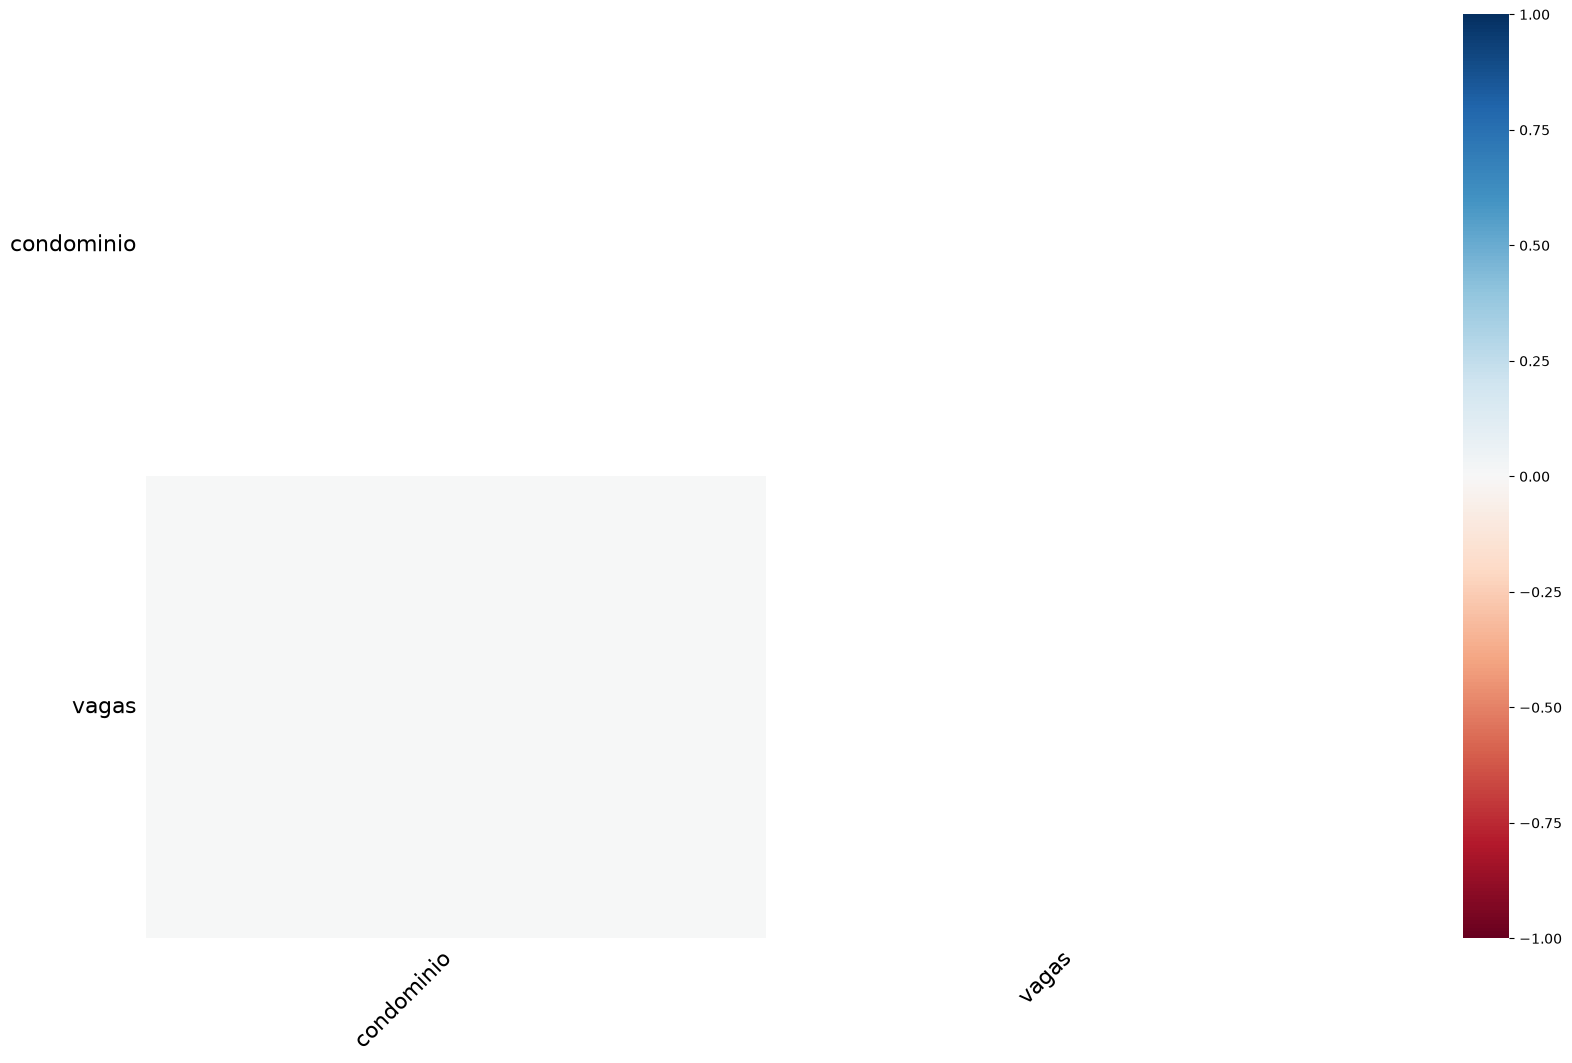

In [50]:
msno.heatmap(df_miss)

Como podemos ver, as duas variáveis não tem quase correlação nenhuma nos seus dados faltantes.

Com essas informações podemos concluir que não existe relação entre os valores faltantes de `vagas` e `condominio`. Além disso, existem muito valores faltantes na variável `condominio`, o que pode ser um problema na etapa de modealgem. Entretanto, por enquanto não faremos nada com os valores faltantes.

## Análise de Outliers

Para fazermos a análise de outliers, vamos treinar um modelo de aprendizado não supervisionado chamado Isolation Forest, que é um modelo de detecção de anomalias.

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.impute import (
    SimpleImputer,
)

random_state = 1667

imputer = SimpleImputer(
    strategy="median"
)

detector = IsolationForest(
    contamination=0.01,
    n_estimators=5000,
    max_samples=0.25,
    random_state=random_state,
    verbose=1,
)

pipeline = Pipeline(steps=[
    ("imputer", imputer),
    ("detector", detector)
])

Além das features que temos, vamos adicionar também a feature `preco_m2`, para calcular o preço por metro quadrado do imóvel.

In [52]:
df["preco_m2"] = df["preco"] / df["area_m2"]

In [53]:
X = df.values

E vamos treinar nosso modelo.

In [54]:
pipeline.fit(X)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    2.8s
[Parallel(n_jobs=1)]: Done 5000 out of 5000 | elapsed:    2.8s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('detector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_

Calcular as previões de outliers.

In [55]:
outlier = pipeline.predict(X)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    2.8s
[Parallel(n_jobs=1)]: Done 5000 out of 5000 | elapsed:    2.8s finished


E vamos adicionar essas informações no nosso dataset, para plotarmos alguns gráficos mais adiante.

In [56]:
df_copy = df.copy()

df_copy["outlier"] = outlier
df_copy["outlier"] = df_copy["outlier"].map({1: "normal", -1: "outlier"})

df_copy = df_copy.sort_values(by="outlier")

Agora, vamos plotar alguns gráficos de dispersão para entendermos melhor esses outliers.

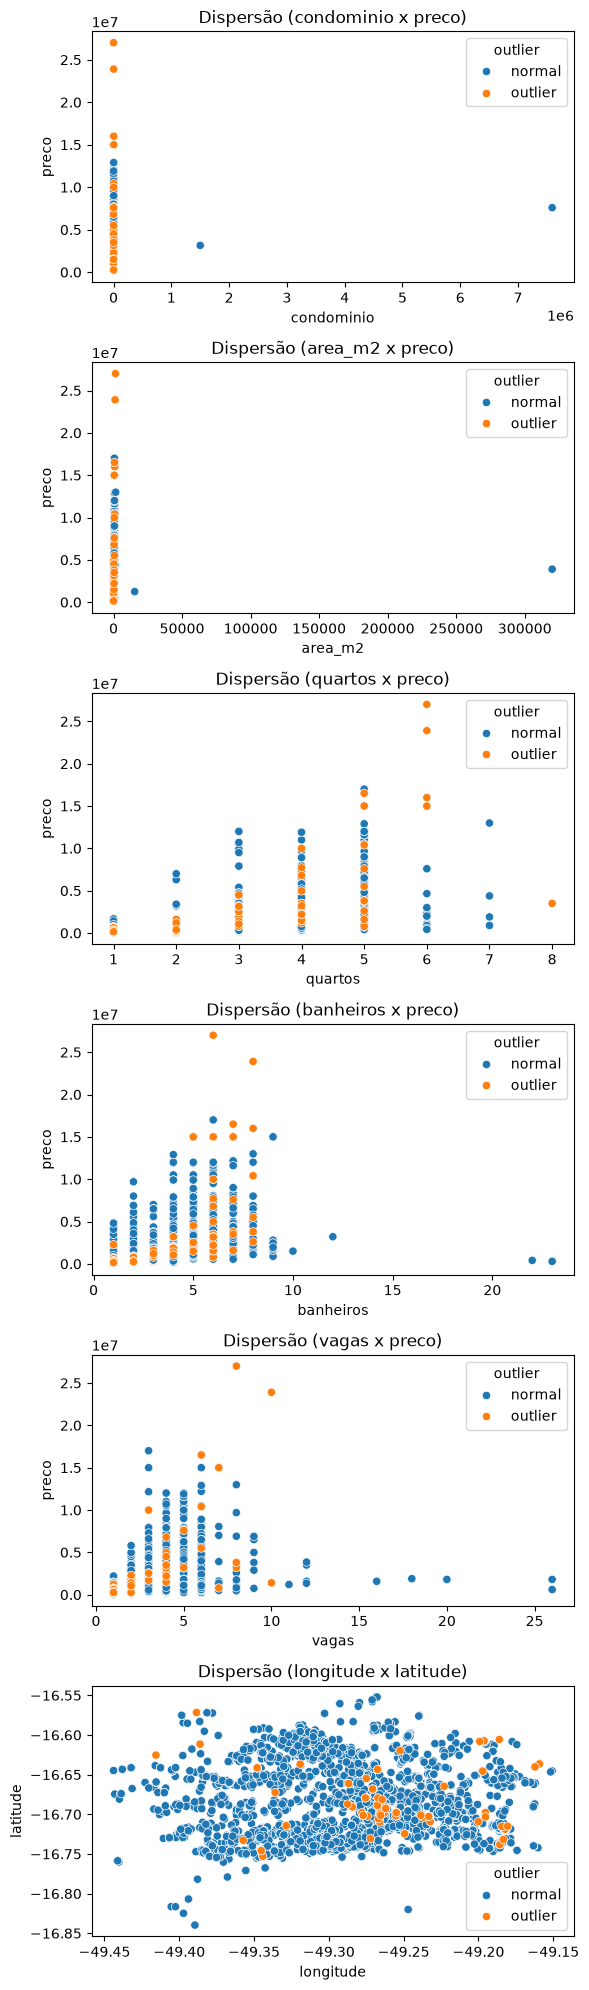

In [57]:
fig, ax = plt.subplots(6, 1, figsize=(6, 20))

for i, feature in enumerate(["condominio", "area_m2", "quartos", "banheiros", "vagas"]):
    sns.scatterplot(data=df_copy, x=feature, y="preco", hue="outlier", ax=ax[i])
    ax[i].set_title(f"Dispersão ({feature} x preco)")

sns.scatterplot(data=df_copy, x="longitude", y="latitude", hue="outlier", ax=ax[5])
ax[5].set_title("Dispersão (longitude x latitude)")

plt.tight_layout()
plt.show()

Como podemos ver, existem alguns outliers de `preco`, mas não parece haver nenhum padrão nos outliers dos primeiros $4$ gráficos. Agora no último temos alguns agrupamentos dos outliers que provavelmente indicam imóveis com preços muito altos. Os pontos mais isolados podem significar imóveis muito baratos. Por enquanto não faremos nada aos outliers, pois eles podem conter informação preditica relevante.